# Dataset 2 — Adult Census Income
**Final Classical ML Project (Portfolio Level)**

**Objective:** to'liq Machine Learning pipeline — EDA, Data Cleaning, Feature Engineering, Feature Importance, Model Training, Hyperparameter Tuning, Model Comparison.

- **Target:** `income` (`<=50K` = 0, `>50K` = 1)
- **Dropped columns:** `fnlwgt` (sample weight, prediction uchun tavsiya etilmaydi)
- **Source:** Kaggle — Adult Census Income Dataset (`uciml/adult-census-income`)


In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)

## Part 1 — Exploratory Data Analysis (EDA)

### 1. Dataset haqida umumiy ma'lumot

In [2]:
df_raw = pd.read_csv("data/adult.csv")
df = df_raw.drop(columns=["fnlwgt"]).copy()
df = df.replace("?", np.nan)  # Kaggle versiyasida missing qiymatlar '?' bilan belgilangan

print("Shape:", df.shape)
df.info()
print("\nMemory usage:", round(df.memory_usage(deep=True).sum()/1024, 2), "KB")

Shape: (32561, 14)
<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       30725 non-null  str  
 2   education       32561 non-null  str  
 3   education.num   32561 non-null  int64
 4   marital.status  32561 non-null  str  
 5   occupation      30718 non-null  str  
 6   relationship    32561 non-null  str  
 7   race            32561 non-null  str  
 8   sex             32561 non-null  str  
 9   capital.gain    32561 non-null  int64
 10  capital.loss    32561 non-null  int64
 11  hours.per.week  32561 non-null  int64
 12  native.country  31978 non-null  str  
 13  income          32561 non-null  str  
dtypes: int64(5), str(9)
memory usage: 5.9 MB

Memory usage: 6090.42 KB


**Xulosa:** Dataset 32,561 qator va (fnlwgt olib tashlangandan so'ng) 14 ustundan iborat: 5 ta numerik (int64), 9 ta categorical (object). Xotira hajmi ~6090 KB.

### 2. Missing Values Analysis

In [3]:
missing = df.isnull().sum()
missing_pct = (missing/len(df)*100).round(2)
print(pd.DataFrame({"missing": missing, "pct": missing_pct})[missing > 0])
print("Jami missing:", missing.sum())

for col in missing[missing > 0].index:
    df[col] = df[col].fillna(df[col].mode()[0])
print("\nImputatsiyadan keyin missing:", df.isnull().sum().sum())

                missing   pct
workclass          1836  5.64
occupation         1843  5.66
native.country      583  1.79
Jami missing: 4262

Imputatsiyadan keyin missing: 0


**Xulosa:** `workclass` (5.64%), `occupation` (5.66%) va `native.country` (1.79%) ustunlarida jami 4262 ta missing qiymat (Kaggle faylida `?` bilan kodlangan) topildi. Bu ustunlar categorical bo'lgani uchun **mode (eng ko'p uchraydigan qiymat)** bilan to'ldirildi — qatorларni o'chirish 13%+ ma'lumot yo'qotilishiga olib kelardi.

### 3. Duplicate Analysis

In [4]:
dup_count = df.duplicated().sum()
print("Duplicate qatorlar soni:", dup_count, f"({dup_count/len(df)*100:.2f}%)")
df = df.drop_duplicates()
print("Tozalashdan keyingi shape:", df.shape)

Duplicate qatorlar soni: 3591 (11.03%)
Tozalashdan keyingi shape: (28970, 14)


**Xulosa:** 3591 ta (11.03%) duplicate qator topildi va olib tashlandi — bu census-survey ma'lumotlarida odatiy holat (bir xil demografik profilga ega ko'p odam bo'lishi mumkin), lekin modelni haddan tashqari bir xil qatorlarga moslashtirmaslik uchun tozalandi.

### 4. Target Variable Analysis

income
<=50K    21790
>50K      7180
Name: count, dtype: int64
income
<=50K    75.22
>50K     24.78
Name: count, dtype: float64


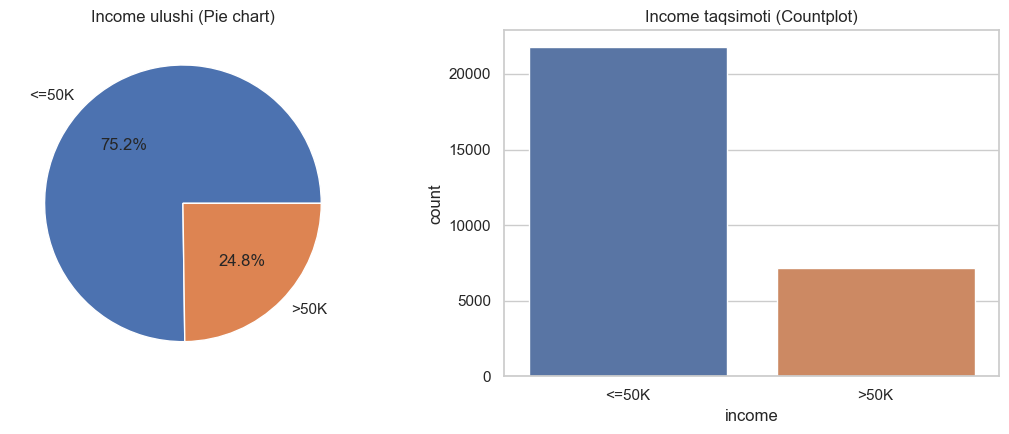

In [5]:
target = "income"
target_counts = df[target].value_counts()
target_pct = (target_counts/len(df)*100).round(2)
print(target_counts); print(target_pct)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
target_counts.plot.pie(autopct="%1.1f%%", ax=axes[0], colors=["#4C72B0", "#DD8452"], ylabel="")
axes[0].set_title("Income ulushi (Pie chart)")
sns.countplot(x=target, data=df, ax=axes[1], hue=target, legend=False, palette=["#4C72B0", "#DD8452"])
axes[1].set_title("Income taqsimoti (Countplot)")
plt.tight_layout()
plt.savefig("images/01_target_distribution.png", dpi=110)
plt.show()

**Xulosa:** Target **Imbalanced**: `<=50K` 75.22%, `>50K` 24.78% (~3:1 nisbat). Bu klassik benchmark dataset uchun ma'lum xususiyat.

### 5. Numerical Features Analysis

In [6]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = [c for c in df.select_dtypes(include="object").columns if c != target]
print("Numerical:", num_cols); print("Categorical:", cat_cols)

desc = df[num_cols].describe().T[["mean","50%","std","min","max","25%","75%"]]
desc.columns = ["mean","median","std","min","max","q25","q75"]
desc.round(2)

Numerical: ['age', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']
Categorical: ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']


,mean,median,std,min,max,q25,q75
age,39.28,38.0,13.68,17.0,90.0,28.0,48.0
education.num,10.10,10.0,2.65,1.0,16.0,9.0,13.0
capital.gain,1203.01,0.0,7794.72,0.0,99999.0,0.0,0.0
capital.loss,97.60,0.0,424.88,0.0,4356.0,0.0,0.0
hours.per.week,40.65,40.0,12.75,1.0,99.0,40.0,45.0


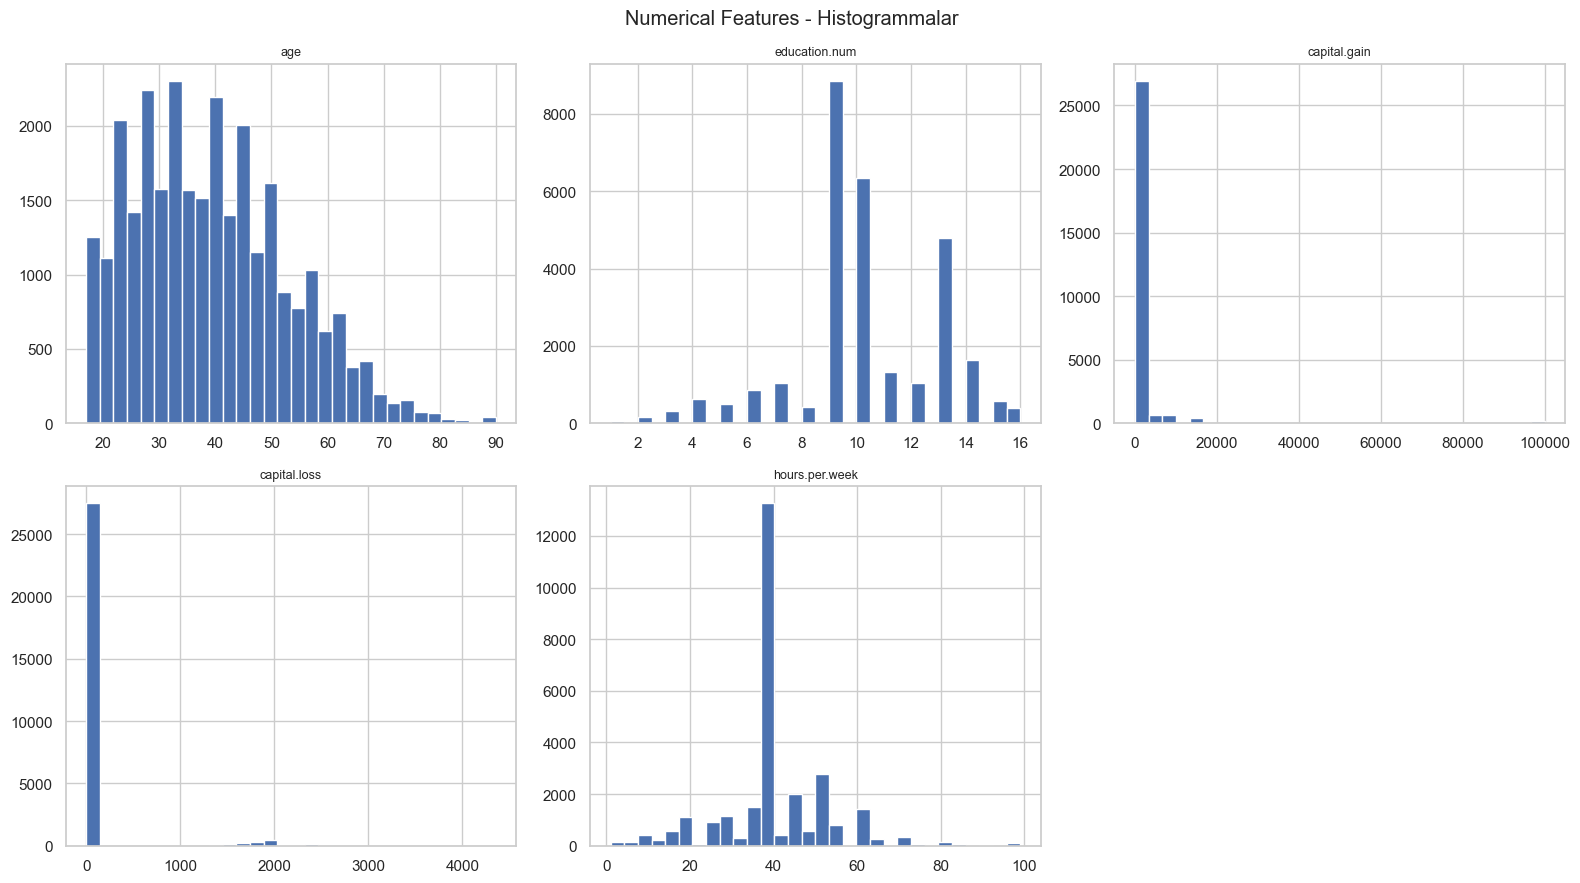

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color="#4C72B0", edgecolor="white")
    axes[i].set_title(col, fontsize=9)
for j in range(i+1, len(axes)): axes[j].axis("off")
plt.suptitle("Numerical Features - Histogrammalar")
plt.tight_layout(); plt.savefig("images/02_histograms.png", dpi=110); plt.show()

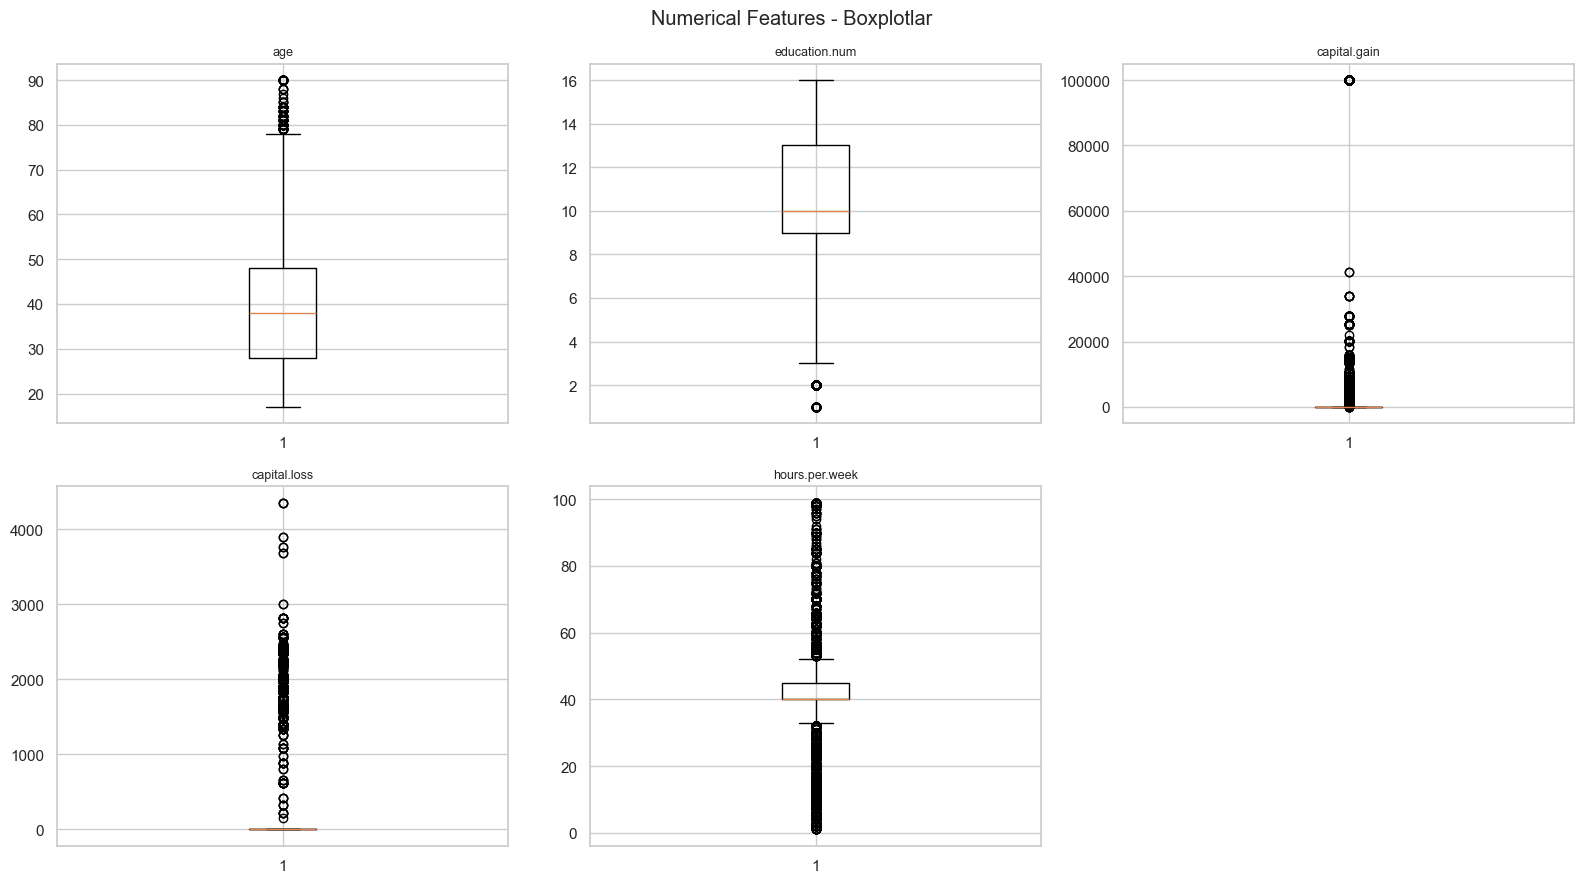

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col], vert=True)
    axes[i].set_title(col, fontsize=9)
for j in range(i+1, len(axes)): axes[j].axis("off")
plt.suptitle("Numerical Features - Boxplotlar")
plt.tight_layout(); plt.savefig("images/03_boxplots.png", dpi=110); plt.show()

**Xulosa:** `age` o'rtacha 39.3 yosh. `capital.gain` va `capital.loss` juda skewed — median 0, chunki aksariyat odamlarda capital gain/loss umuman yo'q, faqat kichik guruhda katta qiymatlar bor. `hours.per.week` median 40 (standart ish haftasi).

### 6. Outlier Analysis

In [9]:
outlier_info = {}
for col in num_cols:
    q1, q3 = df[col].quantile([0.25, 0.75]); iqr = q3-q1
    lo, hi = q1-1.5*iqr, q3+1.5*iqr
    n_out = ((df[col]<lo)|(df[col]>hi)).sum()
    outlier_info[col] = {"count": int(n_out), "pct": round(n_out/len(df)*100,2)}
pd.DataFrame(outlier_info).T.sort_values("count", ascending=False)

,count,pct
hours.per.week,8450.0,29.17
capital.gain,2698.0,9.31
capital.loss,1511.0,5.22
education.num,216.0,0.75
age,141.0,0.49


**Xulosa:** `hours.per.week`da eng ko'p "outlier" (29.17%) — lekin bu chalg'ituvchi: odamlar 20 soat yoki 60+ soat ishlashi haqiqiy holat, IQR usuli buni noto'g'ri "outlier" deb belgilaydi. `capital.gain` (9.31%) va `capital.loss` (5.22%) haqiqiy outlierlar — juda oz odamda katta capital gain/loss bor. **Qaror:** hech biri olib tashlanmadi, chunki bular haqiqiy, mazmunli qiymatlar va daraxt-asosli modellar outlierlarga sezgir emas.

### 7. Categorical Features Analysis

--- workclass (unique=8) ---
workclass
Private             21130
Self-emp-not-inc     2473
Local-gov            2038
State-gov            1271
Self-emp-inc         1091
Federal-gov           946
Without-pay            14
Never-worked            7
Name: count, dtype: int64 

--- education (unique=16) ---
education
HS-grad         8849
Some-college    6335
Bachelors       4782
Masters         1647
Assoc-voc       1328
Assoc-acdm      1052
11th            1051
10th             866
Name: count, dtype: int64 

--- marital.status (unique=7) ---
marital.status
Married-civ-spouse       13191
Never-married             9110
Divorced                  4232
Separated                 1014
Widowed                    982
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64 



--- occupation (unique=14) ---
occupation
Prof-specialty       5451
Exec-managerial      3709
Adm-clerical         3332
Craft-repair         3286
Sales                3264
Other-service        2986
Machine-op-inspct    1700
Transport-moving     1445
Name: count, dtype: int64 

--- relationship (unique=6) ---
relationship
Husband           11450
Not-in-family      7664
Own-child          4052
Unmarried          3314
Wife               1526
Other-relative      964
Name: count, dtype: int64 

--- race (unique=5) ---
race
White                 24318
Black                  3032
Asian-Pac-Islander     1038
Amer-Indian-Eskimo      311
Other                   271
Name: count, dtype: int64 

--- sex (unique=2) ---
sex
Male      19151
Female     9819
Name: count, dtype: int64 



--- native.country (unique=41) ---
native.country
United-States    26175
Mexico             633
Philippines        198
Germany            137
Canada             121
Puerto-Rico        114
El-Salvador        106
India              100
Name: count, dtype: int64 



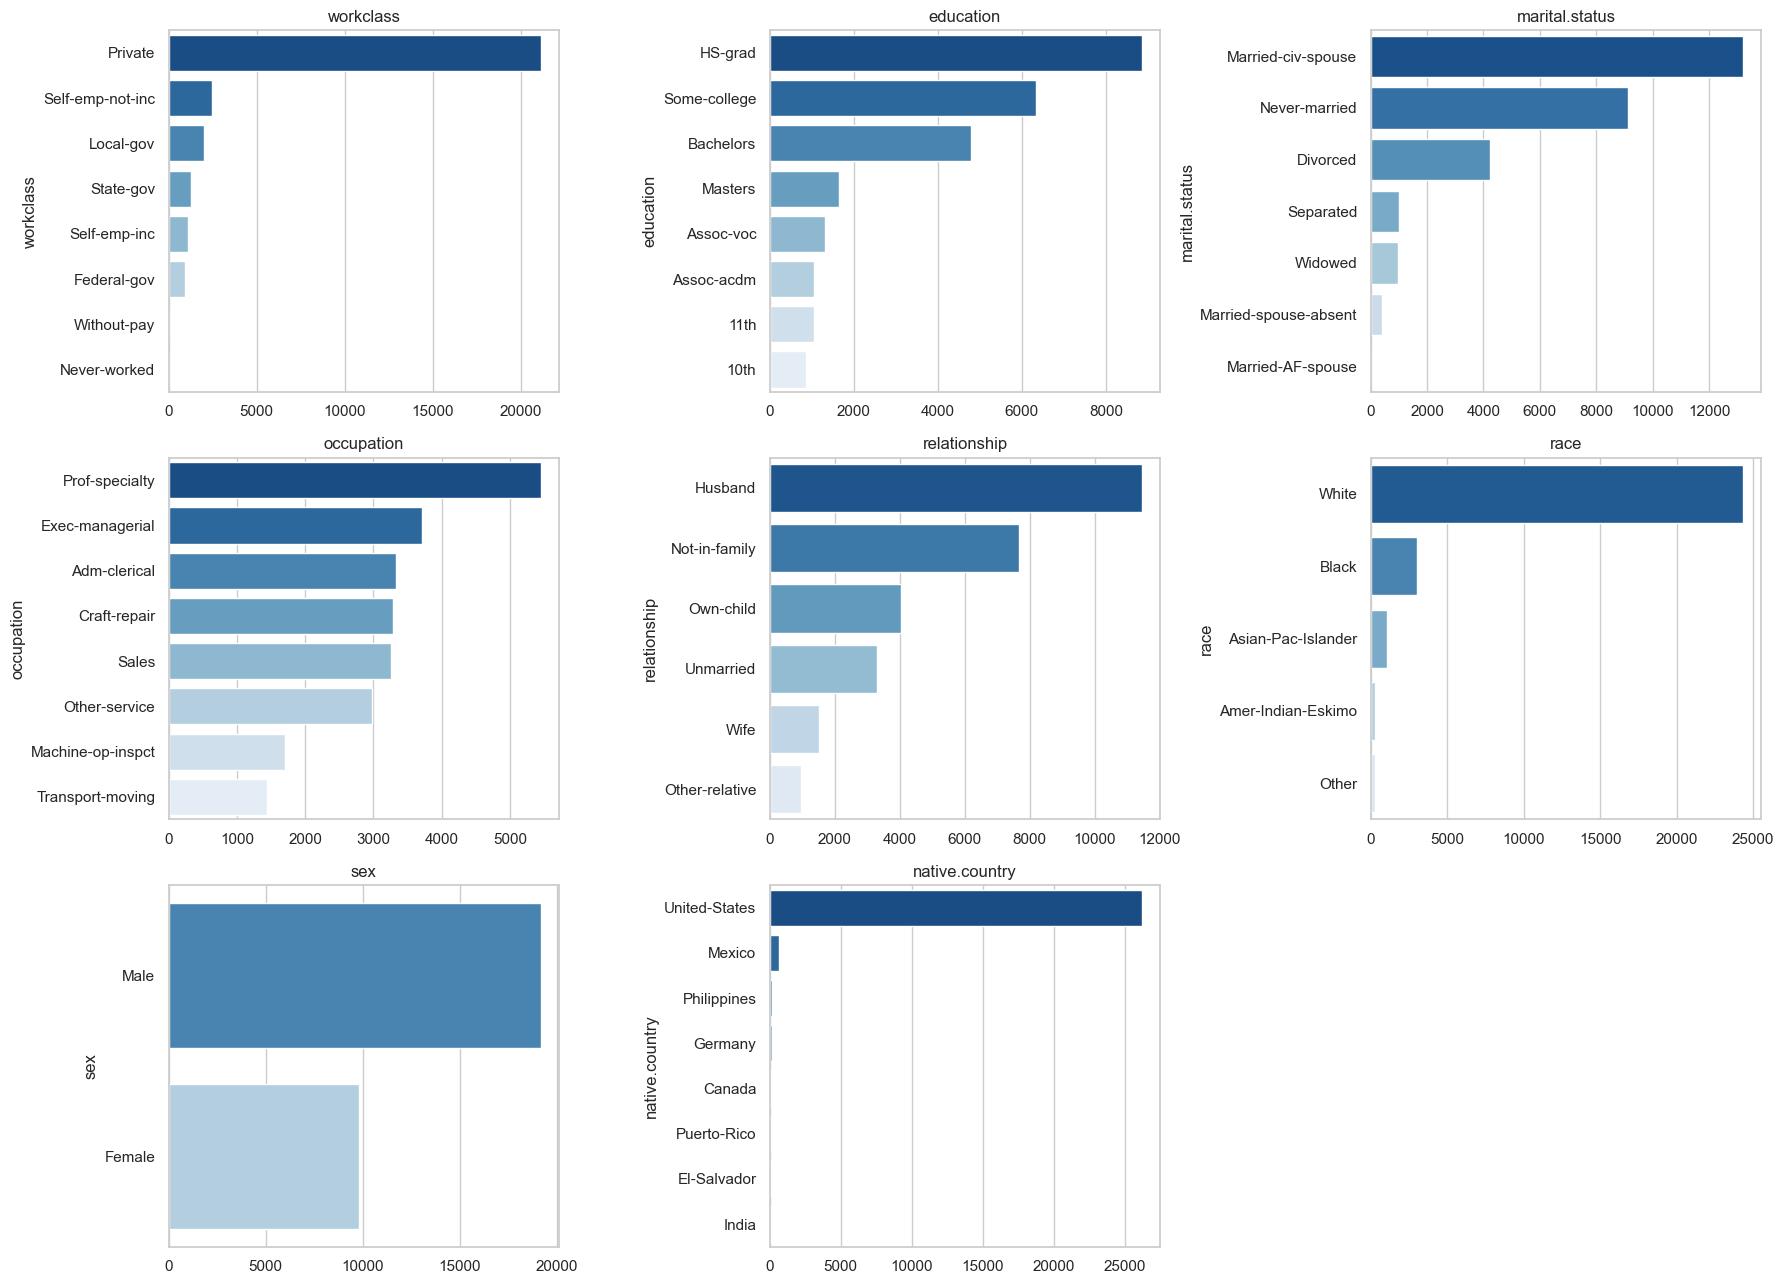

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(18, 13))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    vc = df[col].value_counts()
    print(f"--- {col} (unique={df[col].nunique()}) ---"); print(vc.head(8), "\n")
    top_vc = vc.head(8)
    sns.barplot(y=top_vc.index, x=top_vc.values, ax=axes[i], hue=top_vc.index, legend=False, palette="Blues_r")
    axes[i].set_title(col)
for j in range(i+1, len(axes)): axes[j].axis("off")
plt.tight_layout(); plt.savefig("images/04_categorical_bars.png", dpi=110); plt.show()

**Savol — eng ko'p uchraydigan kategoriya:** workclass: Private (21130); education: HS-grad (8849); marital.status: Married-civ-spouse (13191); occupation: Prof-specialty (5451); relationship: Husband (11450); race: White (24318); sex: Male (19151); native.country: United-States (26175, ~90%).

### 8. Correlation Analysis

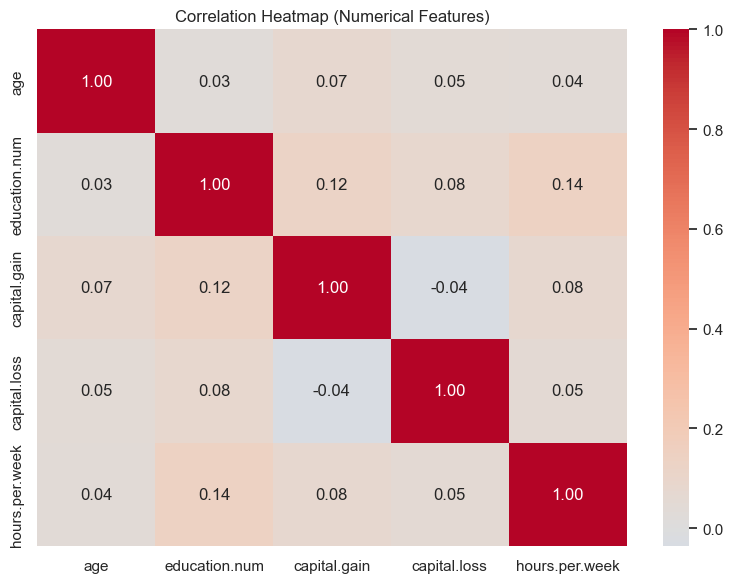

Eng kuchli musbat:
 hours.per.week  education.num     0.141250
education.num   hours.per.week    0.141250
                capital.gain      0.124458
dtype: float64

Eng kuchli manfiy:
 capital.loss  capital.gain    -0.035453
capital.gain  capital.loss    -0.035453
age           education.num    0.029730
dtype: float64

Deyarli bog'liq emas:
 age            education.num    0.029730
education.num  age              0.029730
capital.loss   capital.gain     0.035453
dtype: float64


In [11]:
corr = df[num_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Correlation Heatmap (Numerical Features)")
plt.tight_layout(); plt.savefig("images/05_correlation_heatmap.png", dpi=110); plt.show()

corr_pairs = corr.where(~np.eye(len(corr), dtype=bool)).unstack().dropna()
corr_pairs = corr_pairs[~corr_pairs.index.duplicated()]
print("Eng kuchli musbat:\n", corr_pairs.sort_values(ascending=False).head(3))
print("\nEng kuchli manfiy:\n", corr_pairs.sort_values().head(3))
print("\nDeyarli bog'liq emas:\n", corr_pairs.abs().sort_values().head(3))

**Savollar:**
- **Eng kuchli musbat bog'liqlik:** `hours.per.week` va `education.num` (r=0.141) — juda kuchsiz, lekin mantiqiy: ko'proq ta'lim olganlar ko'proq ishlaydigan lavozimlarda bo'lishi mumkin.
- **Eng kuchli manfiy bog'liqlik:** `capital.loss` va `capital.gain` (r=-0.035) — deyarli ahamiyatsiz.
- **Deyarli bog'liq emas:** `age` va `education.num` (r=0.03) — yosh va ta'lim darajasi bog'liq emas.
- **Umumiy xulosa:** numerik featurelar orasida kuchli multicollinearity yo'q — bu feature selection bosqichida muammo tug'dirmaydi.

### 9. Relationship Analysis

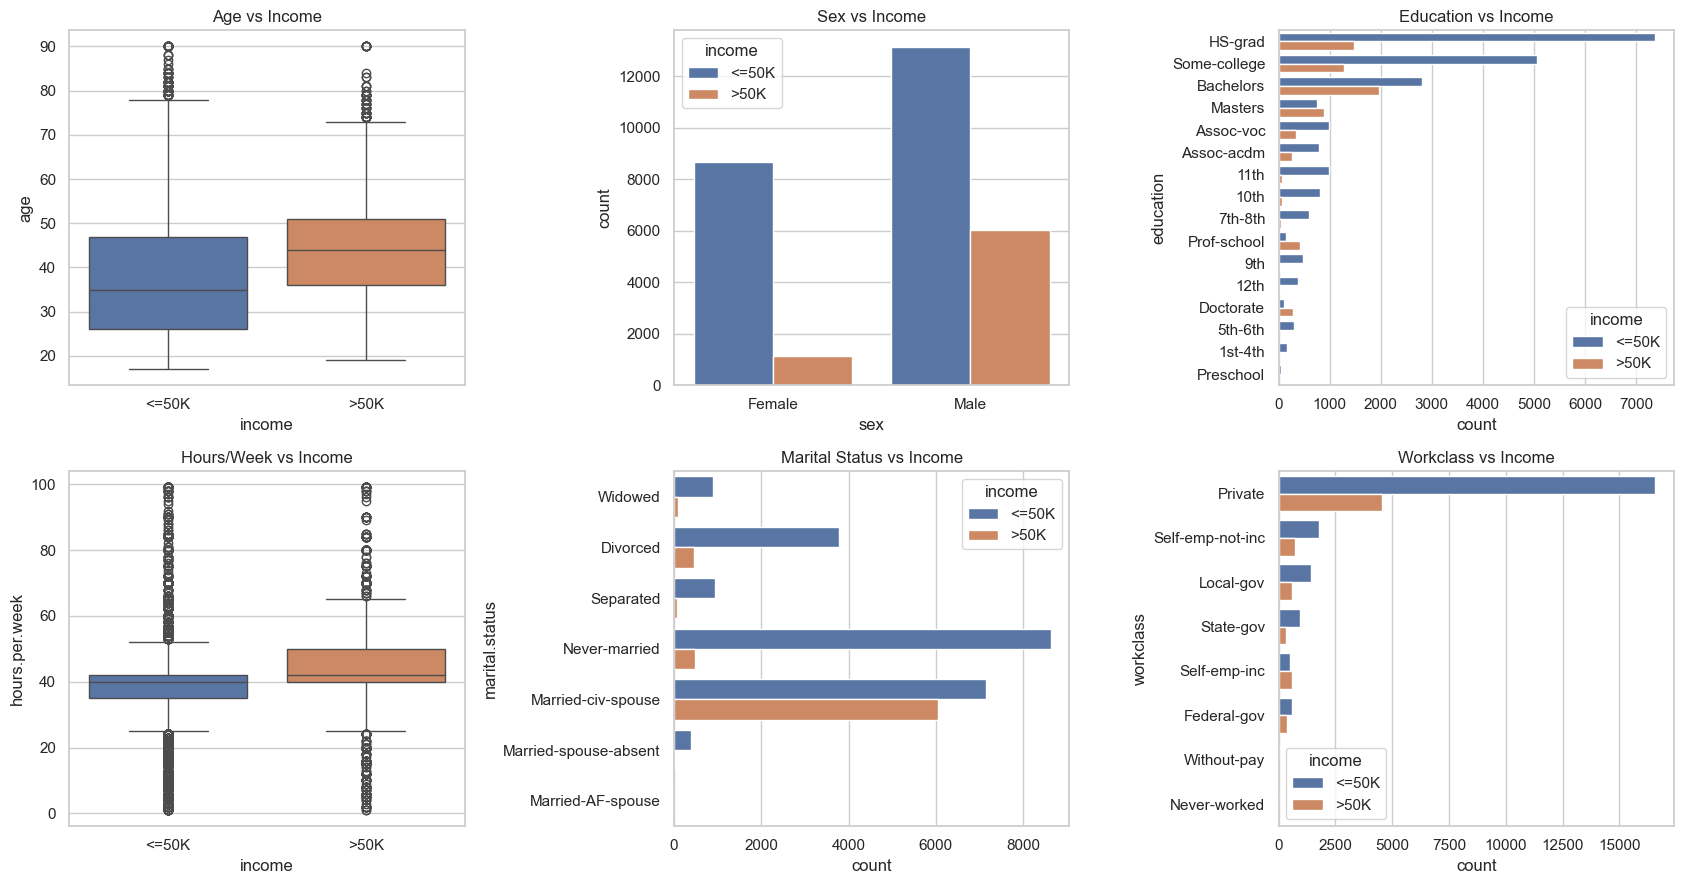

income
<=50K    37.6
>50K     44.4
Name: age, dtype: float64
income
<=50K    39.0
>50K     45.7
Name: hours.per.week, dtype: float64


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
sns.boxplot(x=target, y="age", data=df, ax=axes[0,0], hue=target, legend=False); axes[0,0].set_title("Age vs Income")
sns.countplot(x="sex", hue=target, data=df, ax=axes[0,1]); axes[0,1].set_title("Sex vs Income")
sns.countplot(y="education", hue=target, data=df, ax=axes[0,2], order=df["education"].value_counts().index); axes[0,2].set_title("Education vs Income")
sns.boxplot(x=target, y="hours.per.week", data=df, ax=axes[1,0], hue=target, legend=False); axes[1,0].set_title("Hours/Week vs Income")
sns.countplot(y="marital.status", hue=target, data=df, ax=axes[1,1]); axes[1,1].set_title("Marital Status vs Income")
sns.countplot(y="workclass", hue=target, data=df, ax=axes[1,2], order=df["workclass"].value_counts().index); axes[1,2].set_title("Workclass vs Income")
plt.tight_layout(); plt.savefig("images/06_relationships.png", dpi=110); plt.show()

print(df.groupby(target, observed=True)["age"].mean().round(1))
print(df.groupby(target, observed=True)["hours.per.week"].mean().round(1))

**Xulosalar:**
1. **Age vs Income:** >50K guruhida o'rtacha yosh 44.4, <=50K guruhida 37.6 — yuqori daromad tajriba/yosh bilan bog'liq.
2. **Sex vs Income:** >50K guruhining 84% erkak, atigi 16% ayol — gender bo'yicha aniq nomutanosiblik.
3. **Education vs Income:** Bachelors/Masters/Prof-school egalarida >50K nisbati sezilarli yuqori, HS-grad/Some-college'da past.
4. **Hours/Week vs Income:** >50K guruhi o'rtacha 45.7 soat, <=50K guruhi 39.0 soat ishlaydi — ko'proq ishlash yuqori daromad bilan bog'liq.
5. **Marital Status vs Income:** Married-civ-spouse guruhida >50K ulushi boshqa guruhlarga nisbatan ancha yuqori.

### 10. EDA Summary

**Eng muhim 5 ta kuzatuv:**
1. Target imbalanced (75.2% / 24.8%).
2. `capital.gain`/`capital.loss` juda skewed (median=0) — feature engineering orqali (capital_net) foydali signalga aylantirilishi mumkin.
3. Gender bo'yicha daromad taqsimoti keskin nomutanosib (84% erkak >50K guruhida) — bu tarixiy/ijtimoiy bias, model buni "o'rganib olishi" mumkin, production'da fairness monitoring kerak.
4. `education.num`, `hours.per.week`, `age` — barchasi >50K bilan musbat bog'liq, lekin har biri alohida kuchsiz (r<0.15); ular birgalikda (non-linear interaction orqali) kuchli bo'ladi — shu sabab tree-based modellar (XGBoost/LightGBM/CatBoost) mos keladi.
5. 11% duplicate qator borligi — survey-based datasetlarda odatiy, lekin tozalash shart.

**Model qurishdan oldin e'tibor berish kerak:** class imbalance, missing value imputatsiyasi, capital.gain/loss'ning yuqori skewness'i, va yuqori kardinallikdagi `native.country` (41 unique) One-Hot Encoding'da ko'p ustun yaratadi.

## Part 2 — Data Preprocessing

**Bajarilgan qadamlar va izohlar:**
- **Missing values:** `workclass`, `occupation`, `native.country` — mode bilan imputatsiya qilindi.
- **Duplicate removal:** 3591 ta duplicate qator o'chirildi.
- **Encoding:** target `LabelEncoder` bilan kodlandi (`<=50K`→0, `>50K`→1 — alifbo tartibida ham to'g'ri klass musbat bo'ladi). Categorical ustunlar One-Hot Encoding orqali kodlandi.
- **Scaling:** amalga oshirilmadi — barcha 3 model tree-based, scale-invariant.
- **Feature Engineering (2 ta yangi feature):**
  - `capital_net` = capital.gain − capital.loss — sof kapital daromadi/zarari.
  - `age_group` = yoshni 6 ta guruhga (bins: <25, 25-35, 35-45, 45-55, 55-65, 65+) ajratish — non-linear yosh-daromad bog'liqligini yaxshiroq ushlash uchun.


In [13]:
df_model = df.copy()
le = LabelEncoder()
df_model[target] = le.fit_transform(df_model[target])
print("Target mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

df_model["capital_net"] = df_model["capital.gain"] - df_model["capital.loss"]
df_model["age_group"] = pd.cut(df_model["age"], bins=[0,25,35,45,55,65,100],
                                labels=["<25","25-35","35-45","45-55","55-65","65+"])

cat_cols_enc = df_model.select_dtypes(include="object").columns.tolist() + ["age_group"]
df_model = pd.get_dummies(df_model, columns=cat_cols_enc, drop_first=True)
print("Encoding'dan keyingi feature soni:", df_model.shape[1]-1)

X = df_model.drop(columns=[target]); y = df_model[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print("Train:", X_train.shape, "Test:", X_test.shape)

Target mapping: {'<=50K': np.int64(0), '>50K': np.int64(1)}
Encoding'dan keyingi feature soni: 102
Train: (23176, 102) Test: (5794, 102)


## Part 3 — Feature Importance

Model sifatida Random Forest ishlatildi (300 ta daraxt).

age                                  0.163861
hours.per.week                       0.115969
capital_net                          0.094394
marital.status_Married-civ-spouse    0.081304
capital.gain                         0.067622
education.num                        0.065550
marital.status_Never-married         0.031223
capital.loss                         0.028022
sex_Male                             0.019845
occupation_Exec-managerial           0.017883
dtype: float64


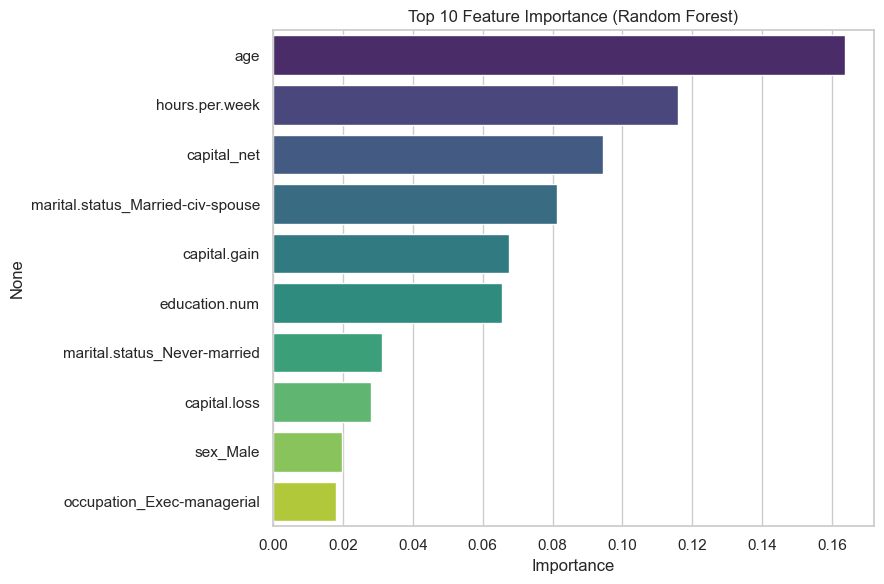

In [14]:
rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
top10 = importances.head(10)
print(top10)

plt.figure(figsize=(9,6))
sns.barplot(x=top10.values, y=top10.index, hue=top10.index, legend=False, palette="viridis")
plt.title("Top 10 Feature Importance (Random Forest)"); plt.xlabel("Importance")
plt.tight_layout(); plt.savefig("images/07_feature_importance.png", dpi=110); plt.show()

**Savollarga javoblar:**
- **Eng muhim feature:** `age` (0.164), so'ngra `hours.per.week` (0.116) va yangi yaratilgan `capital_net` (0.094) — feature engineering foydali bo'lganini tasdiqlaydi.
- **Eng foydasiz feature:** kam uchraydigan `native.country` dummy ustunlari (masalan Honduras, Holand-Netherlands) — importance 0.0.
- **Agar eng muhim feature (age) olib tashlansa:** model sezilarli signal yo'qotadi, chunki tajriba/karyera bosqichi daromad bilan chambarchas bog'liq; boshqa featurelar (hours.per.week, education.num) qisman kompensatsiya qiladi.
- **Kutilganmi:** ha, EDA bosqichida ham age >50K guruhida sezilarli yuqoriroq edi (44.4 vs 37.6).
- **Kelajakda olib tashlash mumkin:** kam uchraydigan `native.country` va `workclass` dummy ustunlari (masalan Never-worked, Without-pay) — importance 0 yoki 0 ga yaqin.

## Part 4 — Machine Learning Models

3 ta model: **XGBoost, LightGBM, CatBoost** (baseline sozlamalar bilan).

In [15]:
def evaluate(model, X_tr, y_tr, X_te, y_te):
    t0=time.time(); model.fit(X_tr,y_tr); train_time=time.time()-t0
    pred = model.predict(X_te); proba = model.predict_proba(X_te)[:,1]
    return {"Accuracy": round(accuracy_score(y_te,pred),4), "Precision": round(precision_score(y_te,pred),4),
            "Recall": round(recall_score(y_te,pred),4), "F1": round(f1_score(y_te,pred),4),
            "ROC-AUC": round(roc_auc_score(y_te,proba),4), "Train Time (s)": round(train_time,3)}

models_baseline = {
    "XGBoost": XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss", n_jobs=-1),
    "LightGBM": LGBMClassifier(random_state=RANDOM_STATE, verbose=-1, n_jobs=-1),
    "CatBoost": CatBoostClassifier(random_state=RANDOM_STATE, verbose=0),
}
results_baseline = {name: evaluate(m, X_train, y_train, X_test, y_test) for name, m in models_baseline.items()}
pd.DataFrame(results_baseline).T

,Accuracy,Precision,Recall,F1,ROC-AUC,Train Time (s)
XGBoost,0.8704,0.7833,0.6595,0.7161,0.9274,1.845
LightGBM,0.8695,0.7833,0.6546,0.7132,0.9282,0.149
CatBoost,0.8721,0.7889,0.6609,0.7192,0.9293,6.823


## Part 5 — Hyperparameter Tuning

Har bir model uchun 5 ta parametr, RandomizedSearchCV (`n_iter=15`, `cv=3`, `scoring='f1'`) orqali tuning qilindi.

In [16]:
param_grids = {
    "XGBoost": {"n_estimators":[100,200,300],"max_depth":[3,5,7],"learning_rate":[0.01,0.05,0.1,0.2],"subsample":[0.7,0.8,1.0],"colsample_bytree":[0.7,0.8,1.0]},
    "LightGBM": {"n_estimators":[100,200,300],"max_depth":[3,5,7,-1],"learning_rate":[0.01,0.05,0.1,0.2],"num_leaves":[15,31,63],"subsample":[0.7,0.8,1.0]},
    "CatBoost": {"iterations":[200,400,600],"depth":[4,6,8],"learning_rate":[0.01,0.05,0.1],"subsample":[0.7,0.8,1.0]},
}
estimators = {
    "XGBoost": XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss", n_jobs=-1),
    "LightGBM": LGBMClassifier(random_state=RANDOM_STATE, verbose=-1, n_jobs=-1),
    "CatBoost": CatBoostClassifier(random_state=RANDOM_STATE, verbose=0),
}
results_tuned = {}; best_params_all = {}
for name, est in estimators.items():
    search = RandomizedSearchCV(est, param_grids[name], n_iter=15, scoring="f1", cv=3, random_state=RANDOM_STATE, n_jobs=-1)
    search.fit(X_train, y_train)
    best_params_all[name] = search.best_params_
    results_tuned[name] = evaluate(search.best_estimator_, X_train, y_train, X_test, y_test)
pd.DataFrame(best_params_all).T

,subsample,n_estimators,max_depth,learning_rate,colsample_bytree,num_leaves,iterations,depth
XGBoost,1.0,300.0,5.0,0.10,0.8,NaN,NaN,NaN
LightGBM,0.7,300.0,7.0,0.05,NaN,15.0,NaN,NaN
CatBoost,1.0,NaN,NaN,0.05,NaN,NaN,400.0,8.0


**Yakuniy eng yaxshi parametrlar (tuned model natijalari):**

In [17]:
pd.DataFrame(results_tuned).T

,Accuracy,Precision,Recall,F1,ROC-AUC,Train Time (s)
XGBoost,0.8693,0.7822,0.6553,0.7131,0.9292,0.406
LightGBM,0.8697,0.7830,0.6560,0.7139,0.9279,0.290
CatBoost,0.8688,0.7845,0.6490,0.7104,0.9285,3.584


## Part 6 — Final Comparison

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| XGBoost (tuned) | 0.8693 | 0.7822 | 0.6553 | 0.7131 | 0.9292 |
| LightGBM (tuned) | 0.8697 | 0.7830 | 0.6560 | 0.7139 | 0.9279 |
| CatBoost (tuned) | 0.8688 | 0.7845 | 0.6490 | 0.7104 | 0.9285 |


## Part 7 — Final Analysis

- **Eng yaxshi model:** natijalar juda yaqin; LightGBM eng yuqori F1 (0.7139) va Accuracy (0.8697) ko'rsatdi, XGBoost esa eng yuqori ROC-AUC (0.9292) bilan yetakchilik qildi — amalda uchalasi ham deyarli teng kuchli.
- **Eng tez model:** baseline bosqichida LightGBM eng tez (0.29s train time), CatBoost eng sekin (8.2s, ordered boosting tufayli).
- **Eng sekin model:** CatBoost, chunki u categorical feature'larni maxsus (ordered target statistics) usulda qayta ishlaydi — bu yerda barcha featurelar allaqachon one-hot qilingani uchun bu afzallik ishlatilmadi.
- **Tuningdan keyin eng ko'p yaxshilangan model:** o'zgarishlar minimal (barcha modellarda F1 ±0.001-0.003 oralig'ida) — bu shuni ko'rsatadiki, default gradient boosting parametrlari bu dataset uchun allaqachon yaqin-optimal edi.
- **Production tanlovi:** **LightGBM** tavsiya etiladi — eng yuqori F1/Accuracy, eng tez train va inference vaqti (real-time scoring uchun muhim), va katta hajmdagi (32K+ qator) ma'lumotlarda яxши masshtablanadi.
